In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# importing the penguins dataset
df = pd.read_csv('penguins (1).csv')
df.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
df.info()
# the dataset has 344 rows and 7 columns. The columns are species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, and
#the sex, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, and sex have some missing values. The species and island columns are categorical variables, while the rest are numerical variables.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [5]:
# checking missing values in each column
missing_values = df.isnull().sum()
print(missing_values)
print('\nTotal missing values:', missing_values.sum())

Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Total missing values: 19


In [6]:
# remove the CSV index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# fill missing numerical values with the median
numeric_columns = df.select_dtypes(include='number').columns
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# fill missing categorical values with the most frequent category
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print('Missing values after cleaning:')
print(df.isnull().sum())
df.head()

Missing values after cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,male,2007
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007


In [7]:
print('Summary statistics:')
display(df.describe())

print('Unique values in categorical columns:')
for column in df.select_dtypes(include='object').columns:
    print(f'\n{column}:')
    print(df[column].value_counts())

Summary statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,344.000000,344.000000,344.000000,344.000000
mean,43.925000,17.152035,200.892442,4200.872093,2008.029070
std,5.443792,1.969060,14.023826,799.696532,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.275000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


Unique values in categorical columns:

species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

sex:
sex
male      179
female    165
Name: count, dtype: int64


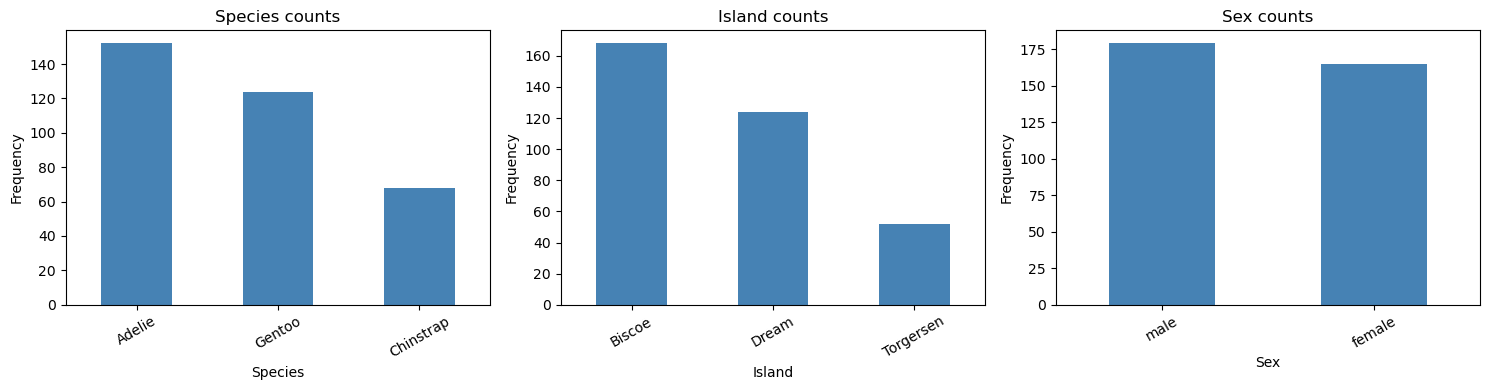

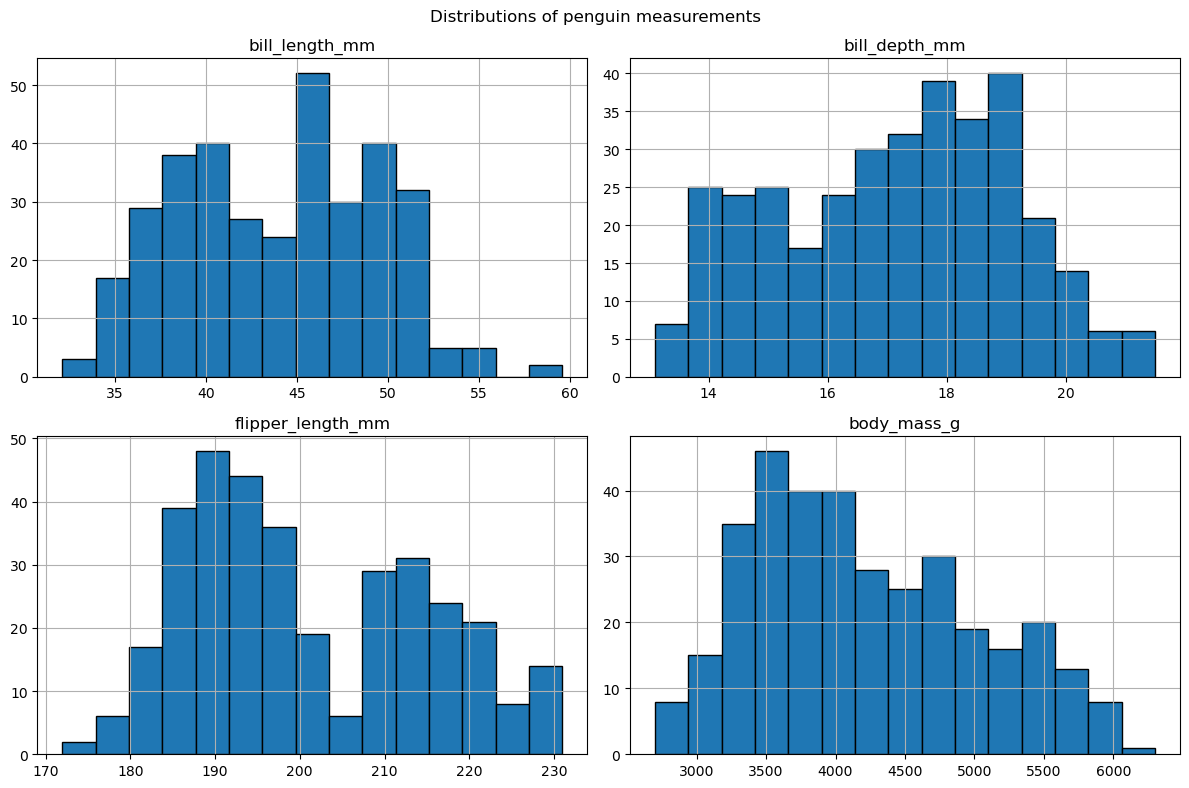

In [8]:
# visualize categorical and numerical distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['species', 'island', 'sex']):
    df[column].value_counts().plot(kind='bar', ax=axis, color='steelblue')
    axis.set_title(f'{column.title()} counts')
    axis.set_xlabel(column.title())
    axis.set_ylabel('Frequency')
    axis.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

numeric_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df[numeric_columns].hist(figsize=(12, 8), bins=15, edgecolor='black')
plt.suptitle('Distributions of penguin measurements')
plt.tight_layout()
plt.show()